In [21]:
import os
import cv2
import numpy as np
import tensorflow as tf
from itertools import combinations
from random import sample, shuffle
from numpy.linalg import norm
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(224, 224, 3)
)

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def get_embedding(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = preprocess(img.astype("float32"))
    img = np.expand_dims(img, axis=0)
    return base_model.predict(img, verbose=0).flatten()


In [22]:
lfw_dir = "lfw-deepfunneled/lfw-deepfunneled"

lfw_dict = {}
for person_name in os.listdir(lfw_dir):
    person_folder = os.path.join(lfw_dir, person_name)
    if os.path.isdir(person_folder):
        images = [os.path.join(person_folder, f) 
                  for f in os.listdir(person_folder) if f.endswith(".jpg")]
        if len(images) >= 2:
            lfw_dict[person_name] = images

print(f"Found {len(lfw_dict)} people with ≥2 images")


Found 1680 people with ≥2 images


In [23]:
MAX_PAIRS = 2000
half_max = MAX_PAIRS // 2

positive_pairs = []
negative_pairs = []

for person, images in lfw_dict.items():
    for img1, img2 in combinations(images, 2):
        positive_pairs.append((img1, img2))

people = list(lfw_dict.keys())
while len(negative_pairs) < len(positive_pairs):
    p1, p2 = sample(people, 2)
    img1 = sample(lfw_dict[p1], 1)[0]
    img2 = sample(lfw_dict[p2], 1)[0]
    negative_pairs.append((img1, img2))

shuffle(positive_pairs)
shuffle(negative_pairs)

positive_subset = positive_pairs[:half_max]
negative_subset = negative_pairs[:half_max]

pairs = positive_subset + negative_subset
labels = [1]*len(positive_subset) + [0]*len(negative_subset)

combined = list(zip(pairs, labels))
shuffle(combined)
pairs, labels = zip(*combined)
pairs = list(pairs)
labels = list(labels)

print(f"Evaluating {len(pairs)} pairs (positive: {labels.count(1)}, negative: {labels.count(0)})")


Evaluating 2000 pairs (positive: 1000, negative: 1000)


In [24]:

import time


start = time.time()

emb_left = []
emb_right = []

print("Generating embeddings for left images...")
for p in tqdm(pairs):
    emb_left.append(get_embedding(p[0]))

print("Generating embeddings for right images...")
for p in tqdm(pairs):
    emb_right.append(get_embedding(p[1]))

emb_left = np.array(emb_left)
emb_right = np.array(emb_right)


Generating embeddings for left images...


  0%|          | 0/2000 [00:00<?, ?it/s]

Generating embeddings for right images...


  0%|          | 0/2000 [00:00<?, ?it/s]

In [25]:
scores = np.array([norm(a-b) for a, b in zip(emb_left, emb_right)])

thresholds = np.linspace(scores.min(), scores.max(), 200)
accuracies = [( (scores < t).astype(int) == np.array(labels) ).mean() for t in thresholds]

best_thresh = thresholds[np.argmax(accuracies)]
best_acc = max(accuracies)
auc = roc_auc_score(labels, -scores) 

print("\n---- LFW Evaluation Results ----")
print("Best Accuracy:", round(best_acc, 4))
print("Optimal Distance Threshold:", round(best_thresh, 4))
print("AUC:", round(auc, 4))



---- LFW Evaluation Results ----
Best Accuracy: 0.7535
Optimal Distance Threshold: 20.2304
AUC: 0.8234


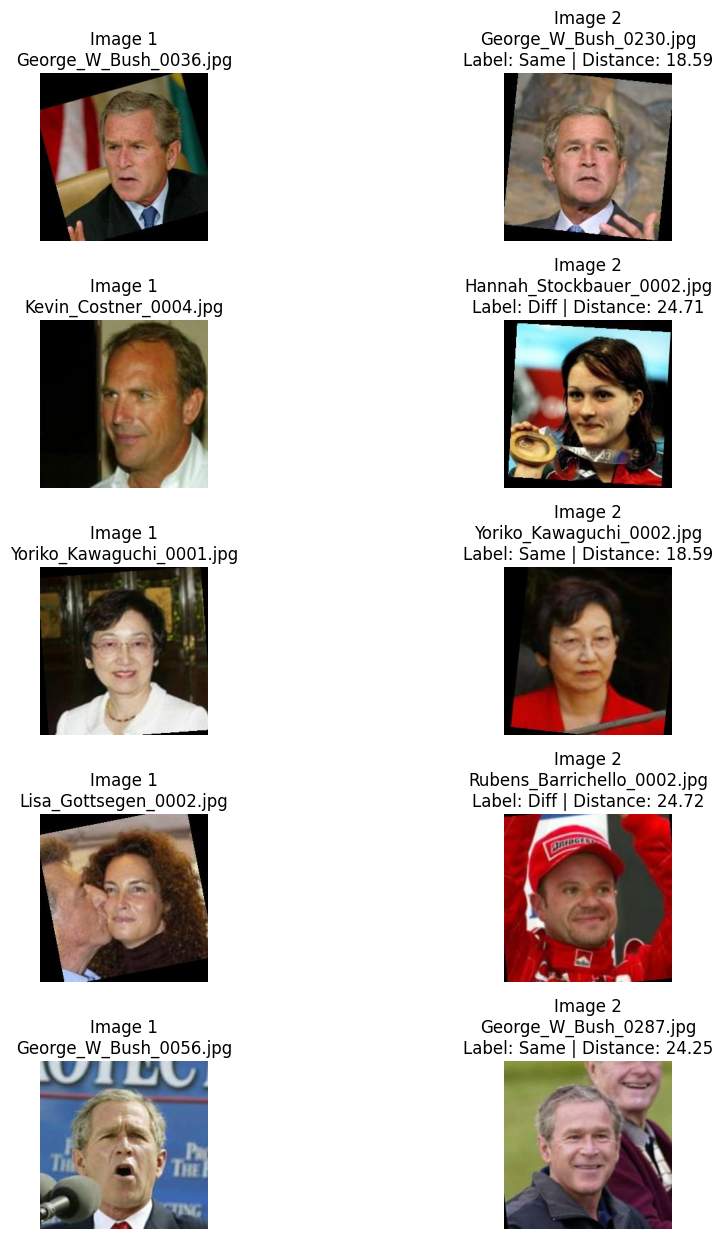

In [26]:
import matplotlib.pyplot as plt

NUM_TO_SHOW = 5

plt.figure(figsize=(12, NUM_TO_SHOW * 2.5))

for i in range(NUM_TO_SHOW):
    img1_path, img2_path = pairs[i]
    label = labels[i]
    score = norm(emb_left[i] - emb_right[i])
    
    img1 = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)
    
    plt.subplot(NUM_TO_SHOW, 2, i*2 + 1)
    plt.imshow(img1)
    plt.axis('off')
    plt.title(f"Image 1\n{os.path.basename(img1_path)}")
    
    plt.subplot(NUM_TO_SHOW, 2, i*2 + 2)
    plt.imshow(img2)
    plt.axis('off')
    plt.title(f"Image 2\n{os.path.basename(img2_path)}\nLabel: {'Same' if label==1 else 'Diff'} | Distance: {score:.2f}")

plt.tight_layout()
plt.show()


In [27]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    accuracy_score, log_loss
)
from sklearn.model_selection import train_test_split
import numpy as np
import time
import pandas as pd


probabilities = 1 - (scores - scores.min()) / (scores.max() - scores.min())
probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)

scores_train, scores_val, labels_train, labels_val, probs_train, probs_val = train_test_split(
    scores, labels, probabilities, test_size=0.2, random_state=42, stratify=labels
)

preds_train = (scores_train < best_thresh).astype(int)
preds_val   = (scores_val < best_thresh).astype(int)

metrics = {
    "Train Accuracy": accuracy_score(labels_train, preds_train),
    "Validation Accuracy": accuracy_score(labels_val, preds_val),
    "Train Loss (Cross Entropy)": log_loss(labels_train, probs_train),
    "Validation Loss (Cross Entropy)": log_loss(labels_val, probs_val),
    "Precision": precision_score(labels_val, preds_val),
    "Recall": recall_score(labels_val, preds_val),
    "F1 Score": f1_score(labels_val, preds_val),
    "AUC": roc_auc_score(labels, -scores),
    "Optimal Threshold": best_thresh,
    "Model Parameters": base_model.count_params(),
}

train_time = time.time() - start
metrics["Processing Time (seconds)"] = round(train_time, 3)

df_metrics = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
display(df_metrics)


,Value
Train Accuracy,7.456250e-01
Validation Accuracy,7.850000e-01
Train Loss (Cross Entropy),5.592858e-01
Validation Loss (Cross Entropy),5.305208e-01
Precision,8.031915e-01
Recall,7.550000e-01
F1 Score,7.783505e-01
AUC,8.233710e-01
Optimal Threshold,2.023044e+01
Model Parameters,2.257984e+06
